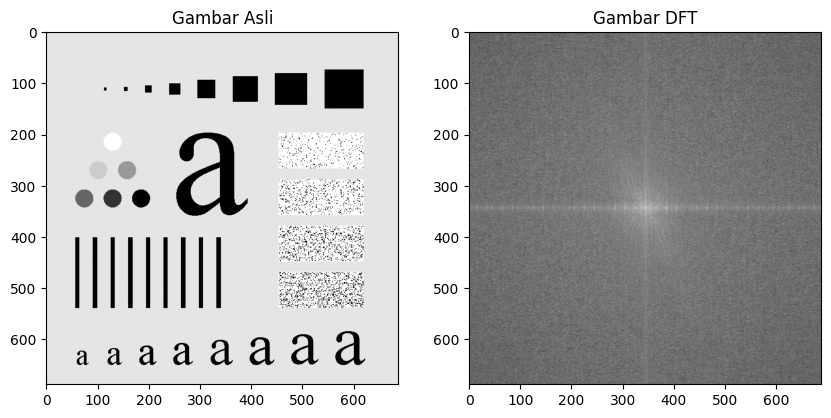

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('./assets/character.tif', 0)

img_dft = np.fft.fft2(img)
img_dft = np.fft.fftshift(img_dft)

show_dft = np.log(np.abs(img_dft))

plt.subplots(1, 2, figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Gambar Asli')

plt.subplot(1, 2, 2)
plt.imshow(show_dft, cmap='gray')
plt.title('Gambar DFT')
plt.show()

Row: 688
Column: 688
Center Row: 344
Center Column: 344


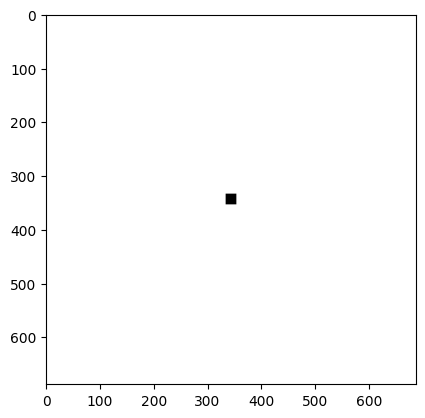

In [2]:
rows, columns = img.shape

center_row = int(rows / 2)
center_column = int(columns / 2)

filter = np.ones((rows, columns), np.uint8)
filter[center_row - 10:center_row + 10, center_column - 10:center_column + 10] = 0

enchance_img = img_dft * filter

print('Row:', rows)
print('Column:', columns)
print('Center Row:', center_row)
print('Center Column:', center_column)

plt.imshow(filter, cmap='gray')
plt.show()

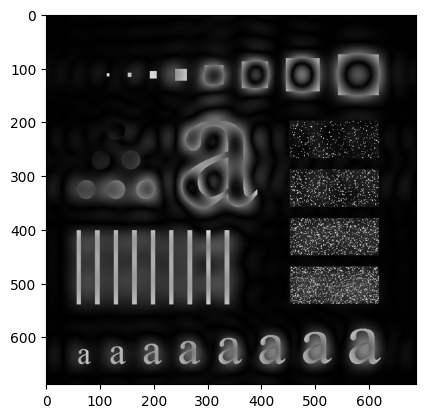

In [3]:
enchance_img = np.fft.ifftshift(enchance_img)
enchance_img = np.fft.ifft2(enchance_img)
enchance_img = np.abs(enchance_img)

plt.imshow(enchance_img, cmap='gray')
plt.show()

In [4]:
# Helper: distance map D(u,v) -> jarak tiap piksel ke titik tengah
# Dibutuhkan oleh filter Gaussian (low-pass & high-pass)
def distance_map(shape):
    rows, columns = shape
    center_row = rows // 2
    center_column = columns // 2
    u = np.arange(rows).reshape(-1, 1)      # vektor kolom (indeks baris)
    v = np.arange(columns).reshape(1, -1)   # vektor baris (indeks kolom)
    d = np.sqrt((u - center_row) ** 2 + (v - center_column) ** 2)
    return d

In [5]:
# Ideal Low-Pass Filter (gaya square mask)
# Kebalikan dari ideal high-pass acuan: tengah = 1 (loloskan frekuensi rendah), sisanya = 0
def ideal_lowpass(shape, size=10):
    rows, columns = shape
    center_row = rows // 2
    center_column = columns // 2
    f = np.zeros((rows, columns), np.uint8)
    f[center_row - size:center_row + size,
      center_column - size:center_column + size] = 1
    return f

In [6]:
# Gaussian Low-Pass & High-Pass Filter (berbasis jarak D)
# Low-pass: tengah ~1, makin jauh makin ->0 (transisi mulus, tanpa ringing)
def gaussian_lowpass(shape, D0=30):
    d = distance_map(shape)
    return np.exp(-(d ** 2) / (2 * (D0 ** 2)))

# High-pass: kebalikan dari low-pass (1 - low-pass)
def gaussian_highpass(shape, D0=30):
    return 1 - gaussian_lowpass(shape, D0)

In [7]:
# Terapkan filter pada spektrum lalu inverse transform -> citra hasil
# Alur sama seperti cell ideal high-pass: ifftshift -> ifft2 -> abs
def apply_filter(img_dft, filter):
    filtered = img_dft * filter
    filtered = np.fft.ifftshift(filtered)
    filtered = np.fft.ifft2(filtered)
    return np.abs(filtered)

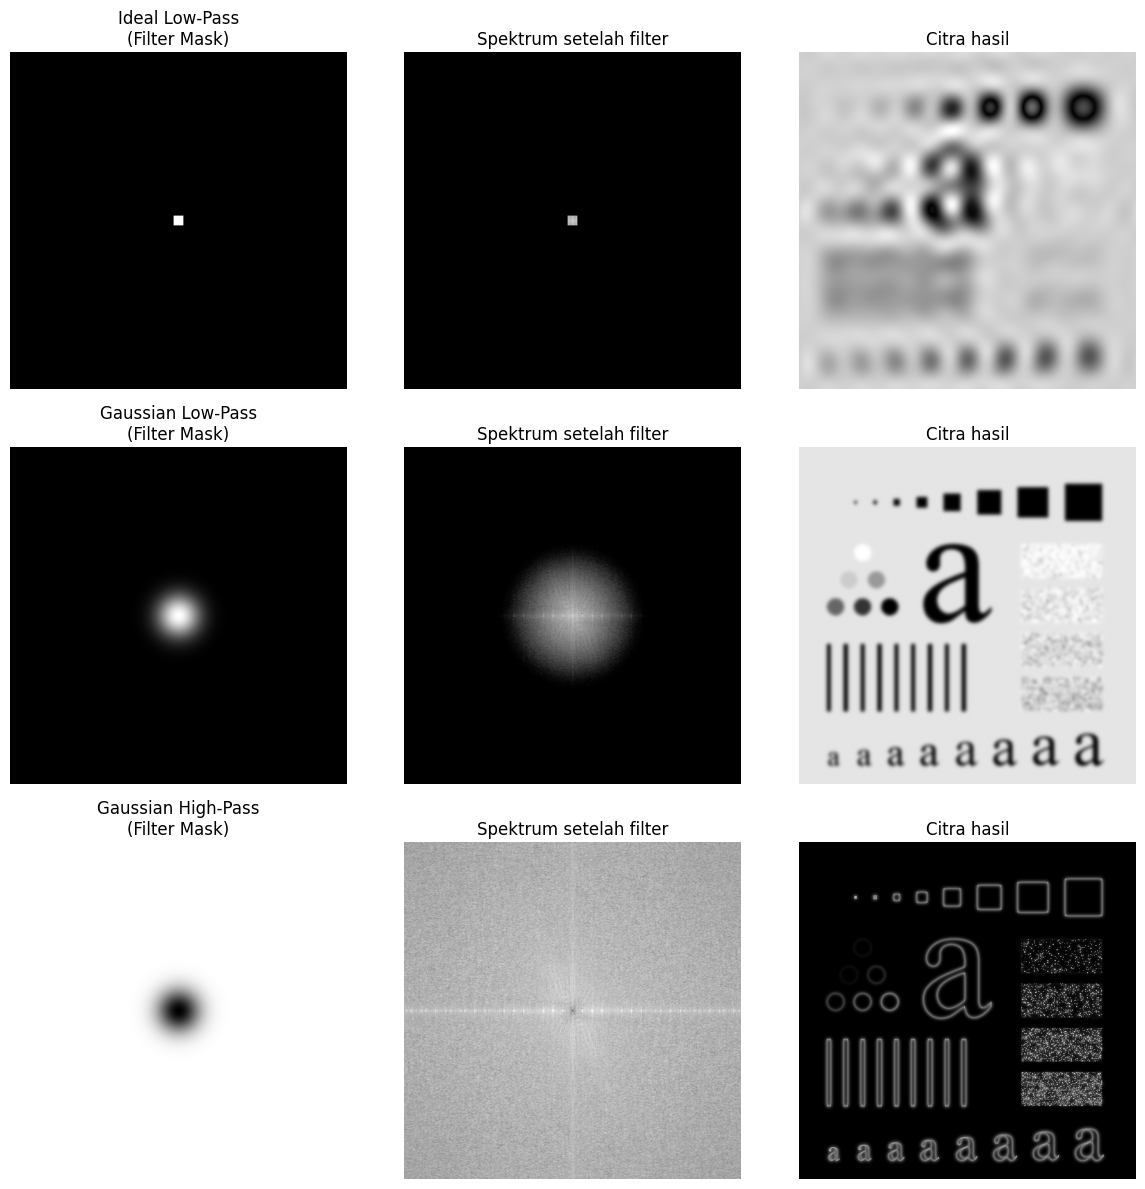

In [8]:
# Perbandingan ketiga filter: mask filter | spektrum setelah filter | citra hasil
filters = {
    'Ideal Low-Pass': ideal_lowpass(img.shape, size=10),
    'Gaussian Low-Pass': gaussian_lowpass(img.shape, D0=30),
    'Gaussian High-Pass': gaussian_highpass(img.shape, D0=30),
}

fig, axes = plt.subplots(len(filters), 3, figsize=(12, 4 * len(filters)))

for row, (name, f) in enumerate(filters.items()):
    result = apply_filter(img_dft, f)
    spectrum = np.log(np.abs(img_dft * f) + 1)  # +1 agar tidak log(0)

    axes[row, 0].imshow(f, cmap='gray')
    axes[row, 0].set_title(f'{name}\n(Filter Mask)')

    axes[row, 1].imshow(spectrum, cmap='gray')
    axes[row, 1].set_title('Spektrum setelah filter')

    axes[row, 2].imshow(result, cmap='gray')
    axes[row, 2].set_title('Citra hasil')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()